In [ ]:
!pip install mlflow

In [2]:
# Here we import the packages we will need
import datetime
import sys
import pandas as pd
import argparse
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn import metrics, linear_model
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import mlflow
import mlflow.sklearn
import logging
import os
import pickle
import json

In [3]:
#import scripts
sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../data"))
#import scripts
from step_b_import_data import DataLoader, FileLoader
from step_b_format_data import CleanData
from step_c_filter_columns import filterColumns


[(0.6509803921568628, 0.807843137254902, 0.8901960784313725), (0.12156862745098039, 0.47058823529411764, 0.7058823529411765), (0.6980392156862745, 0.8745098039215686, 0.5411764705882353), (0.2, 0.6274509803921569, 0.17254901960784313), (0.984313725490196, 0.6039215686274509, 0.6), (0.8901960784313725, 0.10196078431372549, 0.10980392156862745), (0.9921568627450981, 0.7490196078431373, 0.43529411764705883), (1.0, 0.4980392156862745, 0.0), (0.792156862745098, 0.6980392156862745, 0.8392156862745098), (0.41568627450980394, 0.23921568627450981, 0.6039215686274509)]


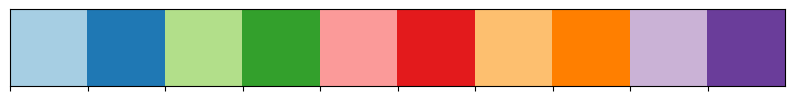

In [3]:
#Set the widths of the columns
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
#Load columnumnors from dataset
palette = sns.color_palette("Paired", 10) 
print(palette) #Prints the RGB tuples that make up the color palette
plotting = sns.palplot(palette)
#setting the colors
blue = palette[1]
red = palette[5]
#Convert the RGB tuple to HEX
def rgb_to_hex(rgb_tuple):
    return "#{:02x}{:02x}{:02x}".format(
        int(rgb_tuple[0]*255),
        int(rgb_tuple[1]*255),
        int(rgb_tuple[2]*255)
    )

#Select colors and convert to hex
bb_hex = rgb_to_hex(palette[0])
blue_hex = rgb_to_hex(palette[1])
gg_hex = rgb_to_hex(palette[2])
green_hex = rgb_to_hex(palette[3])
pink_hex = rgb_to_hex(palette[4])
red_hex = rgb_to_hex(palette[5])
oo_hex = rgb_to_hex(palette[6])
orange_hex = rgb_to_hex(palette[7])
pp_hex = rgb_to_hex(palette[8])
purple_hex = rgb_to_hex(palette[9])

In [4]:
url = "/Users/lawhea1214/Documents/WGU/602/lorraine-w_task2/data/"
fileName = "T_ONTIME_REPORTING.csv"
loader = CleanData(url, fileName) # loads the file
df = loader.dropIt().strip_whitespace().convert_time_columns().get_data()  # Clean the data
df = loader.load_data()  # Load the original data

Dropping nulls...


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107020 entries, 0 to 107019
Data columns (total 34 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   YEAR                   107020 non-null  int64  
 1   QUARTER                107020 non-null  int64  
 2   MONTH                  107020 non-null  int64  
 3   DAY_OF_MONTH           107020 non-null  int64  
 4   DAY_OF_WEEK            107020 non-null  int64  
 5   FL_DATE                107020 non-null  object 
 6   OP_UNIQUE_CARRIER      107020 non-null  object 
 7   OP_CARRIER_AIRLINE_ID  107020 non-null  int64  
 8   OP_CARRIER             107020 non-null  object 
 9   OP_CARRIER_FL_NUM      107020 non-null  int64  
 10  ORIGIN_AIRPORT_ID      107020 non-null  int64  
 11  ORIGIN_AIRPORT_SEQ_ID  107020 non-null  int64  
 12  ORIGIN_CITY_MARKET_ID  107020 non-null  int64  
 13  ORIGIN                 107020 non-null  object 
 14  ORIGIN_CITY_NAME       107020 non-nu

In [6]:
df.loc[:, ['YEAR', 'MONTH', 'DAY_OF_WEEK', 'DAY_OF_MONTH', 'OP_CARRIER_AIRLINE_ID', 'ORIGIN_AIRPORT_ID', 'DEST_AIRPORT_ID', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'ARR_TIME', 'ARR_DELAY', 'AIR_TIME', 'DISTANCE' ]]

,YEAR,MONTH,DAY_OF_WEEK,DAY_OF_MONTH,OP_CARRIER_AIRLINE_ID,ORIGIN_AIRPORT_ID,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,ARR_TIME,ARR_DELAY,AIR_TIME,DISTANCE
0,2024,11,5,1,19805,12478,12892,600,554.0,-6.0,928.0,21.0,343.0,2475.0
1,2024,11,5,1,19805,12892,12478,2258,2254.0,-4.0,647.0,-42.0,275.0,2475.0
2,2024,11,5,1,19805,12892,14100,755,755.0,0.0,1542.0,-26.0,267.0,2402.0
3,2024,11,5,1,19805,12892,12889,800,757.0,-3.0,904.0,-12.0,41.0,236.0
4,2024,11,5,1,19805,12892,13930,500,804.0,184.0,1358.0,168.0,206.0,1744.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107015,2024,11,6,30,19393,14771,14679,725,721.0,-4.0,837.0,-13.0,68.0,447.0
107016,2024,11,6,30,19393,14893,13830,700,659.0,-1.0,1023.0,-22.0,302.0,2404.0
107017,2024,11,6,30,19393,13796,14679,1025,1019.0,-6.0,1153.0,-2.0,74.0,446.0
107018,2024,11,6,30,19393,14679,10397,1240,1246.0,6.0,1939.0,-1.0,205.0,1892.0


In [7]:
#check the conversion for the time columns
df[['CRS_DEP_TIME', 'DEP_TIME', 'ARR_TIME']].head()

,CRS_DEP_TIME,DEP_TIME,ARR_TIME
0,600,554.0,928.0
1,2258,2254.0,647.0
2,755,755.0,1542.0
3,800,757.0,904.0
4,500,804.0,1358.0


In [8]:
#check for nulls
df.isnull().any().any().sum()

1

In [9]:
# #drop the null values
df.dropna(inplace=True)

In [10]:
# #save the cleaned data frame
loader.save_versions(df,"v1") 

In [11]:
filter_data = filterColumns(url, fileName) # loads the file
fc = filter_data.filter('ORIGIN', 'LAX') # load the original data
fc.head()

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST,DEST_CITY_NAME,DEST_STATE_ABR,DEST_STATE_NM,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_NEW,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE
1,2024,4,11,1,5,11/1/2024 12:00:00 AM,AA,19805,AA,10,12892,1289208,32575,LAX,"Los Angeles, CA",CA,12478,1247805,31703,JFK,"New York, NY",NY,New York,2258,2254.0,-4.0,0.0,729,647.0,-42.0,331.0,293.0,275.0,2475.0
2,2024,4,11,1,5,11/1/2024 12:00:00 AM,AA,19805,AA,1002,12892,1289208,32575,LAX,"Los Angeles, CA",CA,14100,1410005,34100,PHL,"Philadelphia, PA",PA,Pennsylvania,755,755.0,0.0,0.0,1608,1542.0,-26.0,313.0,287.0,267.0,2402.0
3,2024,4,11,1,5,11/1/2024 12:00:00 AM,AA,19805,AA,1015,12892,1289208,32575,LAX,"Los Angeles, CA",CA,12889,1288904,32211,LAS,"Las Vegas, NV",NV,Nevada,800,757.0,-3.0,0.0,916,904.0,-12.0,76.0,67.0,41.0,236.0
4,2024,4,11,1,5,11/1/2024 12:00:00 AM,AA,19805,AA,1021,12892,1289208,32575,LAX,"Los Angeles, CA",CA,13930,1393008,30977,ORD,"Chicago, IL",IL,Illinois,500,804.0,184.0,184.0,1110,1358.0,168.0,250.0,234.0,206.0,1744.0
8,2024,4,11,1,5,11/1/2024 12:00:00 AM,AA,19805,AA,1140,12892,1289208,32575,LAX,"Los Angeles, CA",CA,13930,1393008,30977,ORD,"Chicago, IL",IL,Illinois,2349,2339.0,-10.0,0.0,551,542.0,-9.0,242.0,243.0,201.0,1744.0


In [12]:
#save the data to the database
filter_data.save_data()

In [13]:
filter_data.save_versions(fc, "v2")

In [14]:
fc["FL_DATE"].unique()

array(['11/1/2024 12:00:00 AM', '11/2/2024 12:00:00 AM',
       '11/3/2024 12:00:00 AM', '11/4/2024 12:00:00 AM',
       '11/5/2024 12:00:00 AM', '11/6/2024 12:00:00 AM',
       '11/7/2024 12:00:00 AM', '11/8/2024 12:00:00 AM',
       '11/9/2024 12:00:00 AM', '11/10/2024 12:00:00 AM',
       '11/11/2024 12:00:00 AM', '11/12/2024 12:00:00 AM',
       '11/13/2024 12:00:00 AM', '11/14/2024 12:00:00 AM',
       '11/15/2024 12:00:00 AM', '11/16/2024 12:00:00 AM',
       '11/17/2024 12:00:00 AM', '11/18/2024 12:00:00 AM',
       '11/19/2024 12:00:00 AM', '11/20/2024 12:00:00 AM',
       '11/21/2024 12:00:00 AM', '11/22/2024 12:00:00 AM',
       '11/23/2024 12:00:00 AM', '11/24/2024 12:00:00 AM',
       '11/25/2024 12:00:00 AM', '11/26/2024 12:00:00 AM',
       '11/27/2024 12:00:00 AM', '11/28/2024 12:00:00 AM',
       '11/29/2024 12:00:00 AM', '11/30/2024 12:00:00 AM'], dtype=object)

In [15]:
col_lst = ["FL_DATE"]
filter_data.time_convert(col_lst)

,YEAR,QUARTER,MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_NEW,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,ARR_DELAY_NEW,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE
0,2024,4,11,1,0,AA,19805,AA,10,12892,1289208,32575,LAX,"Los Angeles, CA",CA,12478,1247805,31703,JFK,2225,2222.0,-3.0,0.0,654,705.0,11.0,11.0,329.0,343.0,320.0,1.0,2475.0
1,2024,4,11,1,0,AA,19805,AA,1002,12892,1289208,32575,LAX,"Los Angeles, CA",CA,14100,1410005,34100,PHL,755,756.0,1.0,1.0,1608,1601.0,-7.0,0.0,313.0,305.0,280.0,1.0,2402.0
2,2024,4,11,1,0,AA,19805,AA,1015,12892,1289208,32575,LAX,"Los Angeles, CA",CA,12889,1288904,32211,LAS,800,759.0,-1.0,0.0,916,907.0,-9.0,0.0,76.0,68.0,46.0,1.0,236.0
3,2024,4,11,1,0,AA,19805,AA,1021,12892,1289208,32575,LAX,"Los Angeles, CA",CA,13930,1393008,30977,ORD,500,458.0,-2.0,0.0,1110,1109.0,-1.0,0.0,250.0,251.0,221.0,1.0,1744.0
4,2024,4,11,1,0,AA,19805,AA,1110,12892,1289208,32575,LAX,"Los Angeles, CA",CA,11057,1105703,31057,CLT,2255,2252.0,-3.0,0.0,637,643.0,6.0,6.0,282.0,291.0,264.0,1.0,2125.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15686,2024,4,11,7,0,WN,19393,WN,712,12892,1289208,32575,LAX,"Los Angeles, CA",CA,13232,1323202,30977,MDW,1850,1847.0,-3.0,0.0,50,11.0,-39.0,0.0,240.0,204.0,186.0,1.0,1750.0
15687,2024,4,11,7,0,WN,19393,WN,765,12892,1289208,32575,LAX,"Los Angeles, CA",CA,14107,1410702,30466,PHX,1225,1316.0,51.0,51.0,1450,1532.0,42.0,42.0,85.0,76.0,56.0,1.0,370.0
15688,2024,4,11,7,0,WN,19393,WN,859,12892,1289208,32575,LAX,"Los Angeles, CA",CA,14893,1489302,33192,SMF,840,838.0,-2.0,0.0,1015,954.0,-21.0,0.0,95.0,76.0,62.0,1.0,373.0
15689,2024,4,11,7,0,WN,19393,WN,944,12892,1289208,32575,LAX,"Los Angeles, CA",CA,14771,1477104,32457,SFO,645,638.0,-7.0,0.0,805,754.0,-11.0,0.0,80.0,76.0,57.0,1.0,337.0


In [15]:
filter_data.save_data()
filter_data.save_versions(fc, "v3")